# The ramen index 🍜
### "When times get hard, people trade down to instant noodles" — does the ramen index *warn* you a downturn is coming?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A leading tell%3F: Busted](https://img.shields.io/badge/A_leading_tell%3F-Busted-8b949e?style=flat-square)

It's a beloved bit of recession folklore: when money is tight, people swap the restaurant meal for a 30-cent brick of instant noodles — so a **spike in noodle sales is an early warning** that the economy is rolling over, and the noodle makers themselves are a safe place to hide while stocks fall.

This notebook puts that on the clock. We take the closest thing to a real "ramen index" — the **world instant-noodle demand** series (billions of servings a year, from the industry's own association) — and the two noodle stocks you can actually buy: **Nissin (`2897.T`, the Cup Noodle inventor)** and **Toyo Suisan (`2875.T`, the Maruchan maker)**. Then we ask two blunt questions: *does noodle demand rise **before** a downturn?* and *do the noodle stocks beat the market **when** the downturn hits?*

> 📓 **Plain-language layer.** Want the lead-lag cross-correlations, the Newey-West alpha and the recession-window *t*-stats? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Stock prices are real (month-end, yfinance). The "ramen index" is the **WINA** world-demand series — a small, **cited, approximate** hardcoded series (a *labelled proxy*, not a live feed); the recession dates are the **NBER**'s official ones. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
NOOD = "#d97b29"   # a ramen-broth orange for the noodle series

from ramen_recession import data, strategy as st

HAVE_PRICES = data.have_prices()
PX = data.load_prices() if HAVE_PRICES else None
RI = data.load_ramen_index()        # WINA demand (hardcoded, cited) — always available
print("price cache present:", HAVE_PRICES,
      "| ramen index", RI.index[0].year, "->", RI.index[-1].year,
      "| NBER recessions:", [r[0] for r in data.NBER_RECESSIONS])

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2001 → 2026', 'n_stock': 305, 'n_n225': 317, 'll_leads': [-2, -1, 0, 1, 2], 'll_r': [-0.34, 0.31, 0.12, -0.25, -0.03], 'll_t': [-1.51, 1.32, 0.51, -1.05, -0.12], 'll_best_lead': 1, 'll_best_r': -0.25, 'll_best_t': -1.05, 'll_best_p': 0.31, 'll_n': 19, 'dem_in': 2.02, 'dem_out': 1.93, 'dem_diff': 0.09, 'dem_t': 0.02, 'dem_p': 0.98, 'dem_nin': 4, 'dem_nout': 15, 'ri_2005': 85.7, 'ri_2024': 122.0, 'ri_cagr': 1.88, 'dem_2008': -4.2, 'dem_2009': -3.8, 'dem_2020': 9.6, 'dem_2014': -2.7, 'dem_2015': -4.9, 'nis_cagr': 6.14, 'nis_vol': 20.2, 'nis_sharpe': 0.4, 'nis_mdd': -42.7, 'nis_wealth': 4.54, 'toy_cagr': 11.53, 'toy_vol': 25.8, 'toy_sharpe': 0.55, 'toy_mdd': -36.6, 'toy_wealth': 16.02, 'n225_cagr': 4.95, 'n225_vol': 19.2, 'n225_sharpe': 0.35, 'n225_mdd': -62.8, 'n225_wealth': 3.59, 'hold_yrs': 25.4, 'nis_alpha': 6.54, 'nis_beta': 0.2, 'nis_t': 2.03, 'nis_p': 0.044, 'toy_alpha': 12.2, 'toy_beta': 0.31, 'toy_t': 2.79, 'toy_p': 0.006, 'nis_down_beta': 0.47, 'nis_up_beta': -0.05, 'nis_asym': 0.52, 'nis_def': 0, 'toy_down_beta': 0.14, 'toy_up_beta': 0.27, 'toy_asym': -0.13, 'toy_def': 1, 'n_down': 130, 'n_up': 175, 'rec_n': 31, 'nis_rec_mean': -0.6, 'nis_rec_excess': 1.55, 'nis_rec_t': 0.94, 'nis_rec_p': 0.352, 'nis_rec_cum': -25.0, 'toy_rec_mean': 1.37, 'toy_rec_excess': 3.53, 'toy_rec_t': 1.34, 'toy_rec_p': 0.189, 'toy_rec_cum': 17.0, 'n225_rec_mean': -2.15, 'n225_rec_cum': -54.1, 'rec_labels': ['2001 dot-com', '2008 GFC', '2020 COVID'], 'nis_by_rec': [-7.5, -24.6, 7.6], 'toy_by_rec': [6.9, -3.1, 13.0], 'n225_by_rec': [-17.0, -36.5, -13.0], 'wina_lag': 6, 'nber_lag': 12, 'syn_lead': 1, 'syn_lead_r': -0.93, 'syn_lead_t': -15.1, 'syn_down': 0.71, 'syn_up': 0.98, 'syn_plant_down': 0.5, 'syn_plant_up': 1.0}


price cache present: True | ramen index 2005 -> 2024 | NBER recessions: ['2001 dot-com', '2008 GFC', '2020 COVID']


## The answer first

| Question | Answer |
|---|---|
| Does noodle demand **rise before** a downturn? | **No.** Line up demand growth against the stock market a year later and the correlation is a coin-flip (*t* = -1.05). Demand grows about the **same** in recession years (+2.0%) as in good years (+1.9%). |
| Did demand even *spike* in the last recessions? | **Only in 2020.** Global noodle demand actually **fell** in the 2008 crash (-4.2% in 2008, -3.8% in 2009) and fell again in 2014–2016 with *no* recession. The only jump was 2020 (+9.6%) — a COVID pantry-stocking story. |
| Are the noodle *stocks* a safe hide-out? | **Mixed and mild.** They fell in the 2001 and 2008 crashes too — just less than a collapsing Nikkei — and only clearly "won" in 2020. |
| So is 'the ramen index' a real recession signal? | **No — it's a story.** Instant noodles are a booming *Asian growth* market, not a business-cycle instrument. |

> The folklore mixes up two things: a genuine long-run *growth* trend in noodles (real, and nothing to do with recessions) and a *recession warning* (not there).

## 1 · The claim

> *"Instant noodles are the ultimate inferior good: cheap, filling, shelf-stable. When a recession is coming, belts tighten and people trade **down** — so noodle sales climb *ahead of* the downturn. Watch the ramen index and you get an early warning the official statistics won't give you for months. And the noodle makers? A defensive staple that holds up while everything else is crashing."*

It's a genuinely *steelman-able* idea. Instant noodles really are counter-cyclical in microeconomic theory — a classic *inferior good*, demand rising as incomes fall. There are real anecdotes (US instant-ramen sales rose during 2008). The finance version is specific and testable: (1) noodle **demand growth should lead** a market downturn, and (2) the noodle **stocks should out-return the market in recessions**. If both hold, you have a free macro alarm *and* a place to hide.

## 2 · So what?

A working "ramen index" would be a small marvel: a cheap, public, real-time gauge that front-runs the National Bureau of Economic Research — you'd rotate to safety *before* the crash, not after. And a genuinely counter-cyclical staple stock is a rare thing worth real money — a diversifier you can hold instead of bonds. But watch the sleight of hand. "People eat more noodles in hard times" is a claim about **volumes**. "Noodle *sales lead* the cycle" is a claim about **timing**. And "noodle *stocks* beat the market in a recession" is a claim about **prices** — which already have the whole outlook baked in. Three different claims, and we can check each one directly.

## 3 · How would we even know?

Three honest tests:

1. **Does demand *lead*?** Line up each year's noodle-demand growth against the stock market's return *the following year*. A real warning signal means high demand now → a *bad* market later (a clear negative correlation at a positive lead).
2. **Do the stocks beat the market in recessions?** Take the actual NBER recession months (2001, 2008, 2020) and compare each noodle stock's return to the Nikkei's, head-to-head.
3. **Could you even trade it?** The demand figure is published ~6 months *after* the year ends, and the NBER dates a recession ~a year late — so "act on the ramen index" is a rule you can't actually follow in time.

**What would make us say "real tell"?** A demand series that clearly turns up *before* downturns *and* noodle stocks that beat the market when recessions hit — not one lucky COVID data point. Anything less is a barstool story.

## 4 · The teardown — let's actually look

**First, the ramen index itself.** Here is world instant-noodle demand since 2005, with the recession years shaded. If the folklore were right, the line would surge *into* the grey bands.

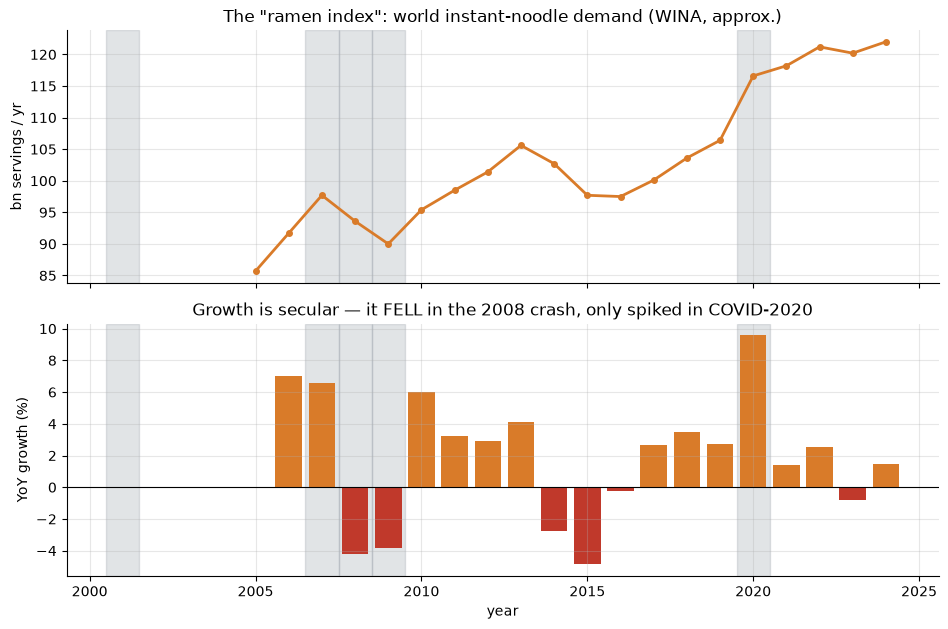

demand 2008 -4.2%  2009 -3.8%  2020 +9.6%  (grey = recession years)


In [2]:
g = data.ramen_growth()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 6.4), sharex=True)
a1.plot(RI.index.year, RI.values, '-o', color=NOOD, lw=2, ms=4)
a1.set_ylabel('bn servings / yr'); a1.set_title('The "ramen index": world instant-noodle demand (WINA, approx.)')
a2.bar(g.index.year, g.values, color=[RED if v<0 else NOOD for v in g.values])
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('YoY growth (%)'); a2.set_xlabel('year')
for yr in sorted({d.year for d in data.recession_months()}):
    for ax in (a1, a2): ax.axvspan(yr-.5, yr+.5, color=GREY, alpha=.25, zorder=0)
a2.set_title('Growth is secular — it FELL in the 2008 crash, only spiked in COVID-2020')
plt.tight_layout(); plt.show()
print(f"demand 2008 {g[g.index.year==2008].iloc[0]:+.1f}%  2009 {g[g.index.year==2009].iloc[0]:+.1f}%  "
      f"2020 {g[g.index.year==2020].iloc[0]:+.1f}%  (grey = recession years)")

Look at the grey bands. In the **2008 GFC** — the deepest, most "trade-down" recession of the sample — global noodle demand *fell* (-4.2% then -3.8%), as a spike in wheat and palm-oil prices pushed volumes down. It also fell in **2014–2016** with no recession at all. The one true jump is **2020** (+9.6%) — people stockpiling instant noodles in lockdown, a supply-shock story, not an economic-warning one. This does not look like a cycle indicator.

**Now the direct test of *leading*.** Does a big noodle-demand year foretell a bad market year? We slide the two series past each other and measure the correlation at each "lead." A genuine early-warning signal shows a **negative** bar at a **positive** lead (demand up now → market down later).

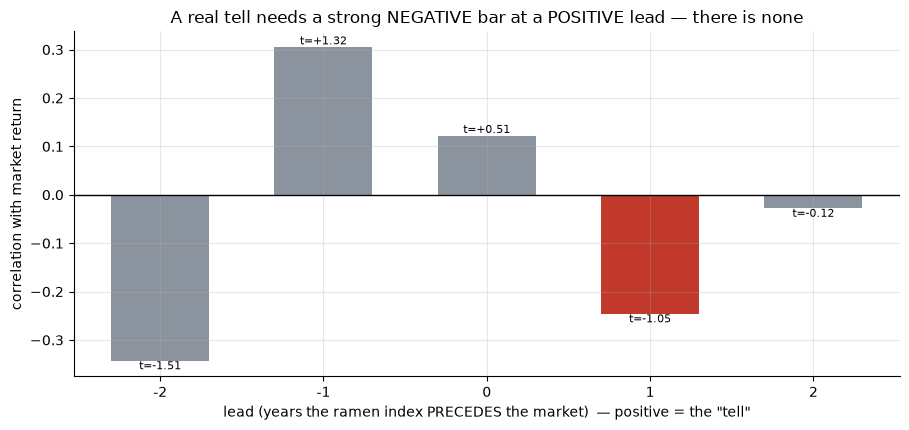

best 'lead' (+1y): r=-0.25  t=-1.05  -> a coin flip


In [3]:
mkt = PX['^N225'].resample('YE').last().pct_change().dropna() if HAVE_PRICES else None
if HAVE_PRICES:
    ll = st.lead_lag_corr(data.ramen_growth()/100.0, mkt, leads=range(-2,3))
    leads = list(ll['per_lead']); rs = [ll['per_lead'][k]['r'] for k in leads]; ts=[ll['per_lead'][k]['t'] for k in leads]
else:
    leads, rs, ts = R['ll_leads'], R['ll_r'], R['ll_t']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [GREY]*len(leads)
for i,k in enumerate(leads):
    if k==R['ll_best_lead']: cols[i]=RED
ax.bar([str(k) for k in leads], rs, .6, color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('lead (years the ramen index PRECEDES the market)  — positive = the "tell"')
ax.set_ylabel('correlation with market return')
for i,k in enumerate(leads): ax.annotate(f't={ts[i]:+.2f}',(i,rs[i]),ha='center',va='bottom' if rs[i]>=0 else 'top',fontsize=8)
ax.set_title('A real tell needs a strong NEGATIVE bar at a POSITIVE lead — there is none')
plt.tight_layout(); plt.show()
print(f"best 'lead' (+{R['ll_best_lead']}y): r={R['ll_best_r']:+.2f}  t={R['ll_best_t']:+.2f}  -> a coin flip")

There is no signal. The "tell" lead (+1 year) is a weak, *insignificant* correlation (*t* = -1.05), and none of the other leads clear the bar either. The single strongest bar is actually at lead **−2** — i.e. if anything the *market* moves before the noodles, the exact opposite of a leading indicator. And the blunt version says the same thing: demand grew **+2.0%/yr** in recession years vs **+1.9%/yr** otherwise — a difference of +0.1% (*t* = 0.02). Statistically indistinguishable.

**So the *tell* fails. What about the *stocks* as a recession hide-out?** Here is how each noodle maker did, compounded, inside each of the three NBER recessions — head-to-head with the Nikkei.

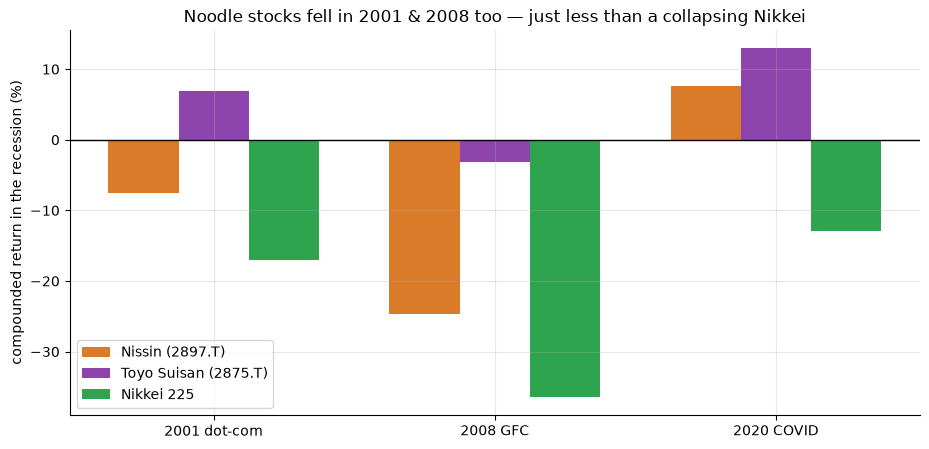

2001 dot-com    Nissin   -7.5%  Toyo   +6.9%  Nikkei  -17.0%
2008 GFC        Nissin  -24.6%  Toyo   -3.1%  Nikkei  -36.5%
2020 COVID      Nissin   +7.6%  Toyo  +13.0%  Nikkei  -13.0%


In [4]:
labels = R['rec_labels']
if HAVE_PRICES:
    br = PX['^N225'].pct_change().dropna()
    nb = st.recession_breakdown(PX['2897.T'].pct_change().dropna(), br, data.NBER_RECESSIONS)
    tb = st.recession_breakdown(PX['2875.T'].pct_change().dropna(), br, data.NBER_RECESSIONS)
    nisv=[nb[l]['stock']*100 for l in labels]; toyv=[tb[l]['stock']*100 for l in labels]; benv=[nb[l]['bench']*100 for l in labels]
else:
    nisv, toyv, benv = R['nis_by_rec'], R['toy_by_rec'], R['n225_by_rec']
x = np.arange(3); fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.bar(x-.25, nisv, .25, color=NOOD, label='Nissin (2897.T)')
ax.bar(x,      toyv, .25, color='#8e44ad', label='Toyo Suisan (2875.T)')
ax.bar(x+.25, benv, .25, color=GREEN, label='Nikkei 225')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('compounded return in the recession (%)')
ax.set_title('Noodle stocks fell in 2001 & 2008 too — just less than a collapsing Nikkei'); ax.legend()
plt.tight_layout(); plt.show()
for i,l in enumerate(labels): print(f'{l:14s}  Nissin {nisv[i]:+6.1f}%  Toyo {toyv[i]:+6.1f}%  Nikkei {benv[i]:+6.1f}%')

It's a mild cushion, not counter-cyclicality. Nissin *fell* in 2001 (−7.5%) and fell hard in the 2008 GFC (−24.6%) — less than the Nikkei's −36.5%, but a loss is a loss. Both names only clearly *won* in **2020** — again the COVID window. "Falls less than a terrible index" is *low beta*, a boring and freely-available property, not a recession alarm.

**And the twist the story never mentions:** over 25 years these noodle stocks actually *beat* the Nikkei outright. Here is \$1 left in each since 2001.

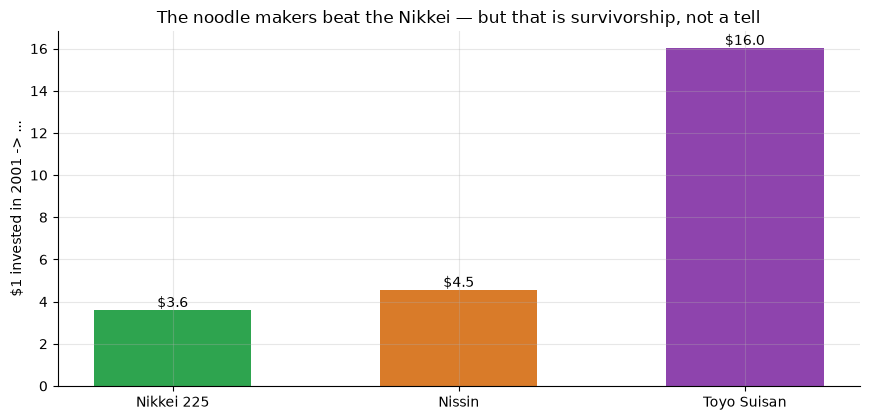

$1 -> Nikkei $3.59  |  Nissin $4.54  |  Toyo Suisan $16.02


In [5]:
if HAVE_PRICES:
    ends = [st.terminal_wealth(PX[t]) for t in ['^N225','2897.T','2875.T']]
else:
    ends = [R['n225_wealth'], R['nis_wealth'], R['toy_wealth']]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['Nikkei 225','Nissin','Toyo Suisan'], ends, .55, color=[GREEN, NOOD, '#8e44ad'])
for i,v in enumerate(ends): ax.annotate(f'${v:.1f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('$1 invested in 2001 -> ...'); ax.set_title('The noodle makers beat the Nikkei — but that is survivorship, not a tell')
plt.tight_layout(); plt.show()
print(f"$1 -> Nikkei ${ends[0]:.2f}  |  Nissin ${ends[1]:.2f}  |  Toyo Suisan ${ends[2]:.2f}")

Yes — \$1 became **\$16** in Toyo Suisan vs just **\$3.6** in the Nikkei. But notice the trick: we hand-picked the two noodle makers that *survived and won*. A defensive staple beating Japan's lost-decades index is the well-known *low-volatility* effect plus **survivorship** — it is not the ramen index telling anyone a recession is coming. (The quant notebook shows this beat clears a significance bar — and why it still isn't the claim.)

## 5 · The verdict

- **Signal — None.** The ramen index does not lead: the best "tell" correlation is *t* = -1.05, and demand grows the same in and out of recessions (*t* = 0.02). The noodle stocks' recession edge is insignificant too (*t* = 0.94 / 1.34).
- **Tradability — Mirage.** You'd learn the year's noodle demand ~6 months late and the recession ~a year late — you can't act on the tell in real time. The only thing that beat the market is two hand-picked survivors, not a signal.
- **A leading tell? — Busted.** Global demand *fell* in the 2008 crash and in 2014–2016; the one spike was COVID-2020. Instant noodles are an Asian growth story, not a business-cycle instrument.

## 6 · Could you actually trade it? — the honest bottom line

Suppose you *believed* it and wanted to use the ramen index as your recession alarm. When would you actually get the reading?

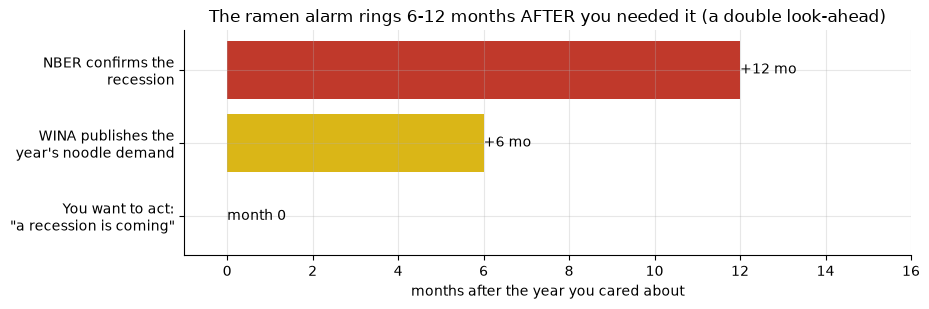

WINA demand lag ~6 mo + NBER lag ~12 mo -> the tell is un-actable in real time


In [6]:
fig, ax = plt.subplots(figsize=(9.4, 3.2))
ax.barh(['You want to act:\n"a recession is coming"','WINA publishes the\nyear\'s noodle demand','NBER confirms the\nrecession'],
        [0, R['wina_lag'], R['nber_lag']], color=[GREEN, AMBER, RED])
for i,v in enumerate([0, R['wina_lag'], R['nber_lag']]): ax.annotate(f'+{v} mo' if v else 'month 0',(v,i),ha='left',va='center')
ax.set_xlabel('months after the year you cared about'); ax.set_xlim(-1, 16)
ax.set_title('The ramen alarm rings 6-12 months AFTER you needed it (a double look-ahead)')
plt.tight_layout(); plt.show()
print(f"WINA demand lag ~{R['wina_lag']} mo + NBER lag ~{R['nber_lag']} mo -> the tell is un-actable in real time")

There it is. Even if the ramen index *had* led the market (it doesn't), the number reaches you half a year after the year it describes, and the recession it was supposed to warn about is confirmed only a year in. "Buy defense when the ramen index spikes" is a rule you can only follow with a time machine. And the one thing that genuinely beat the market here — owning the noodle makers — you can only claim by picking the winners in hindsight. The ramen index is a great bar-story and a poor trading signal.

## 7 · Going further 🚪

- **The US-only tape.** The original anecdote is *American* instant-ramen sales rising in 2008. Pull a US-specific series (Nielsen/IRI) instead of the global WINA figure — does the tell survive on home turf, or is it also just one recession's noise?
- **A real-time nowcast.** Replace the ex-post NBER flag with a Sahm-rule / yield-curve recession probability and re-test whether *any* consumer-staple demand leads it with an honest, no-look-ahead entry.
- **The staples cousins.** The same test on the "lipstick index," discount retail (`DG`, `WMT`), or spam (`HRL`) — is *anything* a real downturn tell, or are they all secular growth stories with one lucky recession? (see [docs/references.md](../docs/references.md)).

*Think a specific noodle series led a recession you can name? Pull its tape, mark the NBER window, and show the lead — then check it wasn't one COVID-shaped data point doing all the work.*